In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv("online_shoppers_intention.csv")

In [3]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
df.shape

(12330, 18)

In [5]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [7]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [8]:
def summarise_dataset(df: pd.DataFrame, target_col: str = 'Revenue'):
    """
    Summarises dataset information including:
    - Shape
    - Data types
    - Missing values
    - Unique values
    - Class distribution
    """
    
    print("=" * 60)
    print("DATASET OVERVIEW")
    print("=" * 60)
    print(f"Rows    : {df.shape[0]:,}")
    print(f"Columns : {df.shape[1]:,}")
    print("=" * 60)

    summary = pd.DataFrame({
        'Data Type': df.dtypes,
        'Missing Values': df.isnull().sum(),
        'Missing (%)': (df.isnull().sum() / len(df) * 100).round(2),
        'Unique Values': df.nunique()
    })

    print("\nCOLUMN SUMMARY\n")
    display(summary)

    total_missing = df.isnull().sum().sum()
    total_cells = df.shape[0] * df.shape[1]

    print(f"\nTotal missing cells: {total_missing:,} / {total_cells:,} "
          f"({(total_missing/total_cells)*100:.2f}%)")

    # Class distribution
    if target_col in df.columns:
        print("\nCLASS DISTRIBUTION\n")
        class_counts = df[target_col].value_counts()
        class_pct = df[target_col].value_counts(normalize=True) * 100

        class_df = pd.DataFrame({
            "Count": class_counts,
            "Percentage (%)": class_pct.round(2)
        })

        display(class_df)

        imbalance_ratio = class_counts.max() / class_counts.min()
        print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")

        if imbalance_ratio > 3:
            print("⚠️ Class imbalance detected.")
        else:
            print("✅ Classes reasonably balanced.")

In [9]:
summarise_dataset(df, target_col='Revenue')

DATASET OVERVIEW
Rows    : 12,330
Columns : 18

COLUMN SUMMARY



,Data Type,Missing Values,Missing (%),Unique Values
Administrative,int64,0,0.0,27
Administrative_Duration,float64,0,0.0,3335
Informational,int64,0,0.0,17
Informational_Duration,float64,0,0.0,1258
ProductRelated,int64,0,0.0,311
ProductRelated_Duration,float64,0,0.0,9551
BounceRates,float64,0,0.0,1872
ExitRates,float64,0,0.0,4777
PageValues,float64,0,0.0,2704
SpecialDay,float64,0,0.0,6



Total missing cells: 0 / 221,940 (0.00%)

CLASS DISTRIBUTION



,Count,Percentage (%)
Revenue,,
False,10422,84.53
True,1908,15.47



Imbalance Ratio: 5.46:1
⚠️ Class imbalance detected.


In [10]:
numeric_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

In [11]:
import os
# ── Subset to numeric features only ───────────────────────────────────────────
df_numeric = df[numeric_features]

# ── Compute Pearson correlation matrix ────────────────────────────────────────
corr_matrix = df_numeric.corr(method='pearson')

# ── Print top correlated pairs (|r| > 0.5, excluding self-correlation) ─────────
print("=" * 60)
print("  CORRELATION MATRIX  —  Pearson r")
print("=" * 60)
print(corr_matrix.round(2).to_string())

print("\n" + "=" * 60)
print("  NOTABLE CORRELATIONS  (|r| > 0.5, excluding diagonal)")
print("=" * 60)
pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
pairs.columns = ['Feature A', 'Feature B', 'r']
pairs['|r|'] = pairs['r'].abs()
notable = pairs[pairs['|r|'] > 0.5].sort_values('|r|', ascending=False)

if notable.empty:
    print("  No pairs with |r| > 0.5 found.")
else:
    for _, row in notable.iterrows():
        direction = "positive" if row['r'] > 0 else "negative"
        print(f"  {row['Feature A']:<28} ↔  {row['Feature B']:<28}  r = {row['r']:+.3f}  ({direction})")

print("=" * 60)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))

# Dark navy background
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

# Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Custom diverging palette: deep blue → white → crimson
cmap = sns.diverging_palette(220, 10, s=90, l=40, as_cmap=True)

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8.5, 'color': 'white', 'weight': 'bold'},
    linewidths=0.4,
    linecolor='#1c2333',
    square=True,
    cbar_kws={'shrink': 0.75, 'pad': 0.02},
    ax=ax,
)

# Colorbar styling
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='#8b949e', labelsize=9)
cbar.outline.set_edgecolor('#30363d')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#8b949e')
cbar.set_label('Pearson  r', color='#8b949e', fontsize=10, labelpad=12)

# Axis labels
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=40, ha='right',
    fontsize=9.5, color='#c9d1d9', fontweight='medium'
)
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=9.5, color='#c9d1d9', fontweight='medium'
)

# Title & subtitle
fig.text(
    0.13, 0.97,
    'Correlation Matrix  —  Numeric Features',
    fontsize=15, fontweight='bold', color='#f0f6fc', va='top'
)
fig.text(
    0.13, 0.935,
    'Online Shoppers Intention Dataset  •  Pearson r  •  Lower triangle',
    fontsize=9.5, color='#8b949e', va='top'
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/correlation_heatmap.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
print("\n  ✅  Heatmap saved → correlation_heatmap.png")
plt.close()

  CORRELATION MATRIX  —  Pearson r
                         Administrative  Administrative_Duration  Informational  Informational_Duration  ProductRelated  ProductRelated_Duration  BounceRates  ExitRates  PageValues  SpecialDay
Administrative                     1.00                     0.60           0.38                    0.26            0.43                     0.37        -0.22      -0.32        0.10       -0.09
Administrative_Duration            0.60                     1.00           0.30                    0.24            0.29                     0.36        -0.14      -0.21        0.07       -0.07
Informational                      0.38                     0.30           1.00                    0.62            0.37                     0.39        -0.12      -0.16        0.05       -0.05
Informational_Duration             0.26                     0.24           0.62                    1.00            0.28                     0.35        -0.07      -0.11        0.03       -0.03


In [12]:
numeric_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "ExitRates",   
    "PageValues",
    "SpecialDay"
]

In [13]:
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (9864, 17)
Test size: (2466, 17)


In [15]:
print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Train distribution:
Revenue
False    0.845296
True     0.154704
Name: proportion, dtype: float64

Test distribution:
Revenue
False    0.845093
True     0.154907
Name: proportion, dtype: float64


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# numeric pipeline
num_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# categorical pipeline
cat_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, numeric_features),
        ("cat", cat_transformer, categorical_features)
    ],
    remainder="drop"
)

preprocess_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor)
])

preprocess_pipeline  # should display pipeline without fitting

,steps,"[('preprocessor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [17]:
# sanity checks
assert "Revenue" not in X.columns
assert set(numeric_features).issubset(X.columns)
assert set(categorical_features).issubset(X.columns)
assert len(set(numeric_features).intersection(set(categorical_features))) == 0

In [18]:
preprocess_pipeline.named_steps["preprocessor"]

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [19]:
preprocess_pipeline.fit(X_train, y_train)
X_train_transformed = preprocess_pipeline.transform(X_train)
X_test_transformed  = preprocess_pipeline.transform(X_test)

print(X_train_transformed.shape, X_test_transformed.shape)

(9864, 74) (2466, 74)


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np

In [21]:
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

In [22]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        n_estimators=200,
        random_state=42
    ))
])

In [23]:
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall"
}

In [25]:
models = {
    "Logistic Regression": logreg_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline
}

results = {}

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )
    
    results[name] = {
        metric: np.mean(scores[f"test_{metric}"])
        for metric in scoring.keys()
    }

results

{'Logistic Regression': {'roc_auc': np.float64(0.9043020138031785),
  'f1': np.float64(0.6166689491566067),
  'precision': np.float64(0.5168764827085784),
  'recall': np.float64(0.7647423122254366)},
 'Random Forest': {'roc_auc': np.float64(0.9266343187381894),
  'f1': np.float64(0.6135531268452168),
  'precision': np.float64(0.749209490721318),
  'recall': np.float64(0.51966141647916)},
 'Gradient Boosting': {'roc_auc': np.float64(0.9314086338547464),
  'f1': np.float64(0.660749878911369),
  'precision': np.float64(0.7183174455897328),
  'recall': np.float64(0.6120647165970213)}}

In [26]:
numeric_features = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "ExitRates", "PageValues", "SpecialDay"
]

categorical_features = [
    "Month",
    "OperatingSystems", "Browser", "Region", "TrafficType",
    "VisitorType",
    "Weekend"
]

In [27]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score

X = df.drop(columns=["Revenue"])
y = df["Revenue"]

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Preprocessing
num_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, numeric_features),
        ("cat", cat_transformer, categorical_features)
    ],
    remainder="drop"
)

# Full model pipeline
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

# CV strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Hyperparameter grid (sensible size)
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 4]
}

grid_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True
)

# Fit
grid_search.fit(X_train, y_train)

print("Best CV ROC-AUC:", grid_search.best_score_)
print("Best params:", grid_search.best_params_)

# Hold-out test ROC-AUC
y_prob = grid_search.best_estimator_.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_prob)
print("Hold-out test ROC-AUC:", test_auc)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END model__learning_rate=0.01, model__max_depth=2, model__n_estimators=100; total time=   1.4s
[CV] END model__learning_rate=0.01, model__max_depth=2, model__n_estimators=100; total time=   1.4s
[CV] END model__learning_rate=0.01, model__max_depth=2, model__n_estimators=100; total time=   1.4s
[CV] END model__learning_rate=0.01, model__max_depth=2, model__n_estimators=100; total time=   1.3s
[CV] END model__learning_rate=0.01, model__max_depth=2, model__n_estimators=100; total time=   1.4s
[CV] END model__learning_rate=0.01, model__max_depth=2, model__n_estimators=200; total time=   2.7s
[CV] END model__learning_rate=0.01, model__max_depth=2, model__n_estimators=200; total time=   2.6s
[CV] END model__learning_rate=0.01, model__max_depth=2, model__n_estimators=200; total time=   2.6s
[CV] END model__learning_rate=0.01, model__max_depth=2, model__n_estimators=200; total time=   2.6s
[CV] END model__learning_rate=0.01, mo

In [28]:
# quick parameter compatibility check
GradientBoostingClassifier().get_params().keys()

dict_keys(['ccp_alpha', 'criterion', 'init', 'learning_rate', 'loss', 'max_depth', 'max_features', 'max_leaf_nodes', 'min_impurity_decrease', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'n_estimators', 'n_iter_no_change', 'random_state', 'subsample', 'tol', 'validation_fraction', 'verbose', 'warm_start'])

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9014598540145985
Precision: 0.7206349206349206
Recall: 0.5942408376963351
F1 Score: 0.6513629842180775

Confusion Matrix:
[[1996   88]
 [ 155  227]]

Classification Report:
              precision    recall  f1-score   support

       False       0.93      0.96      0.94      2084
        True       0.72      0.59      0.65       382

    accuracy                           0.90      2466
   macro avg       0.82      0.78      0.80      2466
weighted avg       0.90      0.90      0.90      2466



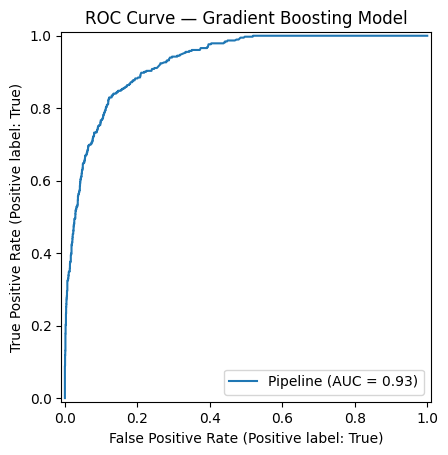


  ✅  ROC Curve saved → roc_curve.png


In [30]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(best_model, X_test, y_test)

plt.title("ROC Curve — Gradient Boosting Model")
plt.show()

plt.savefig("outputs/roc_curve.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
print("\n  ✅  ROC Curve saved → roc_curve.png")
plt.close()

In [31]:
import pandas as pd

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

importances = best_model.named_steps["model"].feature_importances_

feat_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feat_importance.head(10)

plt.savefig("outputs/feature_importance.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
print("\n  ✅  Feature Importance saved → feature_importance.png")
plt.close()


  ✅  Feature Importance saved → feature_importance.png
